# Recorte del Tablero y Particion en 81 Casillas

Notebook de desarrollo del **cropper**: dada una foto, recorta el tablero detectado por YOLO, lo rectifica a una vista cuadrada y lo parte en sus **81 casillas** (9x9), generando un conjunto de imagenes.

- **Kernel:** `py312_arm` (Python 3.12, arm64) con **MPS**
- Modulo: [`src/cropper.py`](../src/cropper.py) | Requiere el detector entrenado (`models/sudoku_detector.pt`).

Pasos: detectar -> rectificar perspectiva -> partir en 81 -> guardar las casillas.

## 0. Entorno

In [1]:
import sys, os, glob
from pathlib import Path
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("../src"))
import detector, cropper

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
print("device:", DEVICE)

def show(img, title="", ax=None):
    ax = ax or plt.gca()
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img.ndim == 3 else img, cmap=None if img.ndim == 3 else "gray")
    ax.set_title(title); ax.axis("off")

device: mps


## 1. Foto de entrada + deteccion

Tomamos una foto real de test y detectamos el marco con el `SudokuDetector` ya entrenado.

caja detectada (x1,y1,x2,y2,conf): [99.3, 289.8, 901.0, 1109.0, 0.9]


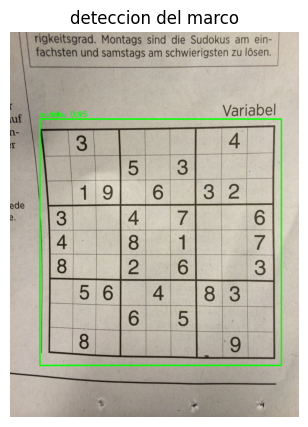

In [2]:
det = detector.SudokuDetector(device=DEVICE)   # carga models/sudoku_detector.pt
test_imgs = sorted(glob.glob("../data/images/test/*.jpg"))
img = cv2.imread(test_imgs[0])

vis, d = det.detect_and_draw(img)
print("caja detectada (x1,y1,x2,y2,conf):", None if d is None else [round(v, 1) for v in d])
plt.figure(figsize=(4, 5)); show(vis, "deteccion del marco"); plt.show()

## 2. Rectificar el tablero

Dentro de la caja YOLO se afinan las 4 esquinas reales del tablero y se aplica `warpPerspective` para obtener una vista cuadrada de frente.

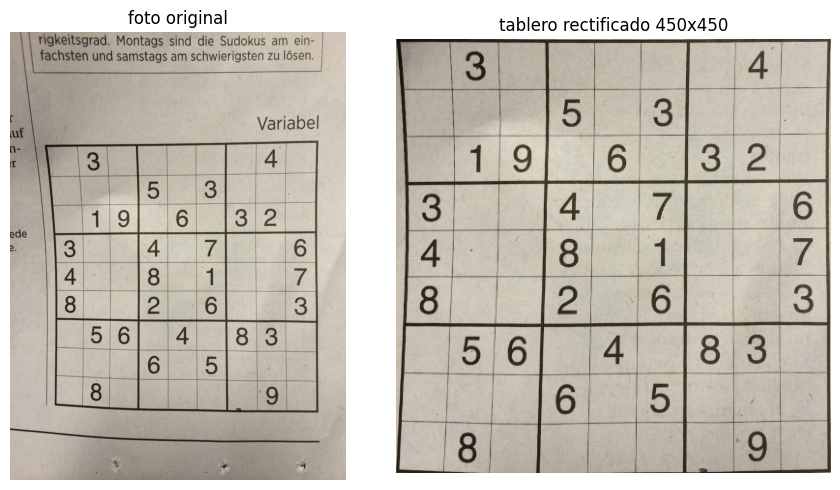

forma del tablero: (450, 450, 3)


In [3]:
crop = cropper.SudokuCropper(det=det, size=450)
board, M = crop.crop_board(img)

fig, ax = plt.subplots(1, 2, figsize=(9, 5))
show(img, "foto original", ax[0]); show(board, "tablero rectificado 450x450", ax[1])
plt.tight_layout(); plt.show()
print("forma del tablero:", board.shape)

## 3. Partir en 81 casillas

`split_cells` divide el tablero en una rejilla 9x9. Las mostramos todas.

casillas: 9x9 = 81
tamano de una casilla: (50, 50, 3)


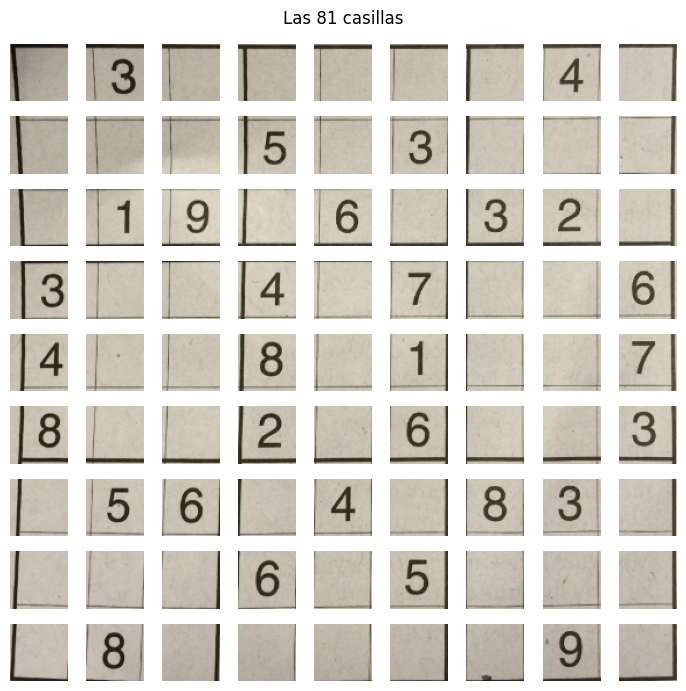

In [4]:
cells = cropper.split_cells(board, grid=9)
n = sum(len(row) for row in cells)
print(f"casillas: {len(cells)}x{len(cells[0])} = {n}")
print("tamano de una casilla:", cells[0][0].shape)

fig, axes = plt.subplots(9, 9, figsize=(7, 7))
for r in range(9):
    for c in range(9):
        axes[r][c].imshow(cv2.cvtColor(cells[r][c], cv2.COLOR_BGR2RGB)); axes[r][c].axis("off")
plt.suptitle("Las 81 casillas"); plt.tight_layout(); plt.show()

## 4. Guardar las casillas como imagenes

`save_cells` escribe cada casilla como `cell_r{r}_c{c}.png`. Genera el conjunto de fotos que consumira el reconocedor.

In [5]:
out_dir = Path("../data/celdas_demo")
n = cropper.save_cells(cells, out_dir)
print(f"Guardadas {n} casillas en {out_dir.resolve()}")
print("ejemplos:", sorted(os.listdir(out_dir))[:5], "...")

Guardadas 81 casillas en /Users/nora/Documentos_Clase/BOOTCAMP/sudoku/data/celdas_demo
ejemplos: ['cell_r0_c0.png', 'cell_r0_c1.png', 'cell_r0_c2.png', 'cell_r0_c3.png', 'cell_r0_c4.png'] ...


## 5. Todo en una llamada: `SudokuCropper.to_cells`

La API que usa el resto del proyecto: de la foto a las 81 casillas en un paso.

In [6]:
board2, cells2 = crop.to_cells(img)
assert len(cells2) == 9 and len(cells2[0]) == 9
print("to_cells OK -> tablero", board2.shape, "y", sum(len(r) for r in cells2), "casillas")
print("\nUso por CLI: python src/cropper.py foto.jpg salida/  ->  board.png + 81 casillas en salida/cells/")

to_cells OK -> tablero (450, 450, 3) y 81 casillas

Uso por CLI: python src/cropper.py foto.jpg salida/  ->  board.png + 81 casillas en salida/cells/
